## import python libraries
## References

- Paleomagnetic source: Murthy,G.S., Gower,C., Tubett,M., Patzold,R. (1992). Paleomagnetism of Eocambrian Long Range dykes and Double Mer Formation from Labrador, Canada. Canad.J.Earth Sci., 29, 1224-1234.
- Geochronology / age-constraint note (compilation): 207Pb/206Pb zircon and baddeleyite ages of 615±2 Ma from Kamo et al., 1989. PR85-631 are from dike 2


In [2]:
import sys
sys.path.append('../data/')
from pole_tools import *
import matplotlib.pyplot as plt

Laurentia_poles = get_Laurentia_poles() # get all poles
Laurentia_stricto_poles = get_Laurentia_stricto_poles() # get only Laurentia poles

%config InlineBackend.figure_format='retina'
%matplotlib inline

In [3]:
R2_test('Long Range Dykes',Laurentia_poles)

N = 92 (N ≥ 25; sufficient sample number);
B = 5 (B < 8; insufficient site number);
K = 1000 (K ≥ 70; concern about underrepresenting PSV);
A_95 of 17.4 passes Deenen et al. (2011) criteria of being between 6.3 and 29.7 for this number of sites


The dike reported in the pre-2022 Nordic workshop compilation is "Dykes 1,2,3,4 and 6" which means that it includes the 3 dikes considered to be primary by Murthy et al. (1992) as well as 2 of the dikes that were deemed to be anomalous.

Here is the pole calculated during the dec = 110.3 and inc = 56.8 from that compilation:

In [4]:
pmag.dia_vgp(110.3,56.8,14.1,53.7,303.3)

(355.33067944510805, 19.032565077309133, 14.846196162479012, 20.46124951663285)

However, we are not able to reproduce this directional mean using the data from Murthy for those sites:

In [ ]:
Murthy_sites_geo, Murthy_sites_tc = load_magic_sites('../data/615_Long_Range/sites.txt')
Murthy_data = Murthy_sites_tc if not Murthy_sites_tc.empty else Murthy_sites_geo
Murthy_data = Murthy_data.rename(columns={'dir_dec': 'dec', 'dir_inc': 'inc', 'lat': 'site_lat', 'lon': 'site_lon'}).reset_index(drop=True)
Murthy_data.head()

,site,N,dec,inc,k,a95,site_lat,site_lon
0,Dyke 2,3,117.3,47.4,52,17.3,53.7,303.3
1,Dyke 4,7,133.1,51.2,48,8.8,53.7,303.3
2,Dyke 6,2,124.8,55.5,48,18.0,53.7,303.3
3,Dyke 1,3,215.3,-75.5,67,15.2,53.7,303.3
4,Dyke 3,1,249.8,-49.2,43,16.4,53.7,303.3


In [6]:
pmag.flip?

Signature: pmag.flip(di_block, combine=False)
Docstring:
Determines 'normal' direction along the principle eigenvector, then flips 
the reverse mode to the antipode.

Parameters
----------
di_block : nested list of directions
combine : whether to return directions as one di_block (default is False)
    
Returns
-------
D1 : normal mode
D2 : flipped reverse mode as two DI blocks
If combine=True one combined D1 + D2 di_block will be returned
File:      ~/0000_GitHub/PmagPy/pmagpy/pmag.py
Type:      function


In [8]:
Murthy_di_diblock = ipmag.make_di_block(Murthy_data['dec'],Murthy_data['inc'])
Murthy_dis = pmag.flip(Murthy_di_diblock, combine=True)

In [9]:
ipmag.reversal_test_MM1990(Murthy_data['dec'],Murthy_data['inc'])

Results of Watson V test: 

Watson's V:           9.8
Critical value of V:  22.1
"Pass": Since V is less than Vcrit, the null hypothesis
that the two populations are drawn from distributions
that share a common mean direction can not be rejected.

M&M1990 classification:

Angle between data set means: 34.9
Critical angle for M&M1990:   53.4
The McFadden and McElhinny (1990) classification for
this test is: 'INDETERMINATE;


(1, 34.910337942203896, 53.35602708530494, 'indeterminate')

In [12]:
Murthy_di_mean = ipmag.fisher_mean(di_block=Murthy_dis)
ipmag.print_direction_mean(Murthy_di_mean)

Dec: 105.5  Inc: 59.8
Number of directions in mean (n): 5
Angular radius of 95% confidence (a_95): 21.6
Precision parameter (k) estimate: 13.5


In [31]:
pmag.dia_vgp(Murthy_di_mean['dec'],Murthy_di_mean['inc'],Murthy_di_mean['alpha95'],53.7,303.3)

(356.4155128630335, 23.892297209549078, 24.52456042547461, 32.53671207790338)

In [20]:
LRD_pole_lon_di, LRD_pole_lat_di, LRD_pole_dp_di, LRD_pole_dm_di = pmag.dia_vgp(Murthy_di_mean['dec'],Murthy_di_mean['inc'],Murthy_di_mean['alpha95'],53.7,303.3)

In [21]:
ipmag.vgp_calc(Murthy_data, tilt_correction='no', dec_is='dec', inc_is='inc')
Murthy_data

,site,N,dec,inc,k,a95,site_lat,site_lon,paleolatitude,vgp_lat,vgp_lon,vgp_lat_rev,vgp_lon_rev
0,Dyke 2,3,117.3,47.4,52,17.3,53.7,303.3,28.534956,8.420945,355.409084,-8.420945,175.409084
1,Dyke 4,7,133.1,51.2,48,8.8,53.7,303.3,31.876430,4.709223,341.773018,-4.709223,161.773018
2,Dyke 6,2,124.8,55.5,48,18.0,53.7,303.3,36.036059,11.589915,345.975123,-11.589915,165.975123
3,Dyke 1,3,215.3,-75.5,67,15.2,53.7,303.3,-62.650405,-69.687982,173.187072,69.687982,353.187072
4,Dyke 3,1,249.8,-49.2,43,16.4,53.7,303.3,-30.081807,-35.510209,209.359815,35.510209,29.359815


In [22]:
Murthy_data_diblock = ipmag.make_di_block(Murthy_data['vgp_lon'],Murthy_data['vgp_lat'])
Murthy_vgp_n, Murthy_vgp_r = pmag.flip(Murthy_data_diblock)
Murthy_vgps = Murthy_vgp_n
for i in Murthy_vgp_r:
    Murthy_vgps.append(i)
LRD_pole = ipmag.fisher_mean(di_block=Murthy_vgps)
ipmag.print_pole_mean(LRD_pole)

Plon: 356.1  Plat: 26.3
Number of directions in mean (n): 5
Angular radius of 95% confidence (A_95): 32.0
Precision parameter (k) estimate: 6.7


In [23]:
# let's do  a three site mean calculation for the Long Range dikes using 2,4,6
Murthy_data_good_sites = Murthy_data[Murthy_data['site'].str.contains('2|4|6')]
Long_range_246_mean = ipmag.fisher_mean(dec = Murthy_data_good_sites['vgp_lon'],
                                       inc = Murthy_data_good_sites['vgp_lat'])
Long_range_246_mean

{'dec': 347.70579069072693,
 'inc': 8.280652967159275,
 'n': 3,
 'r': 2.981828665503921,
 'k': 110.06346289159772,
 'alpha95': 11.807469376774494,
 'csd': 7.720820086907034}

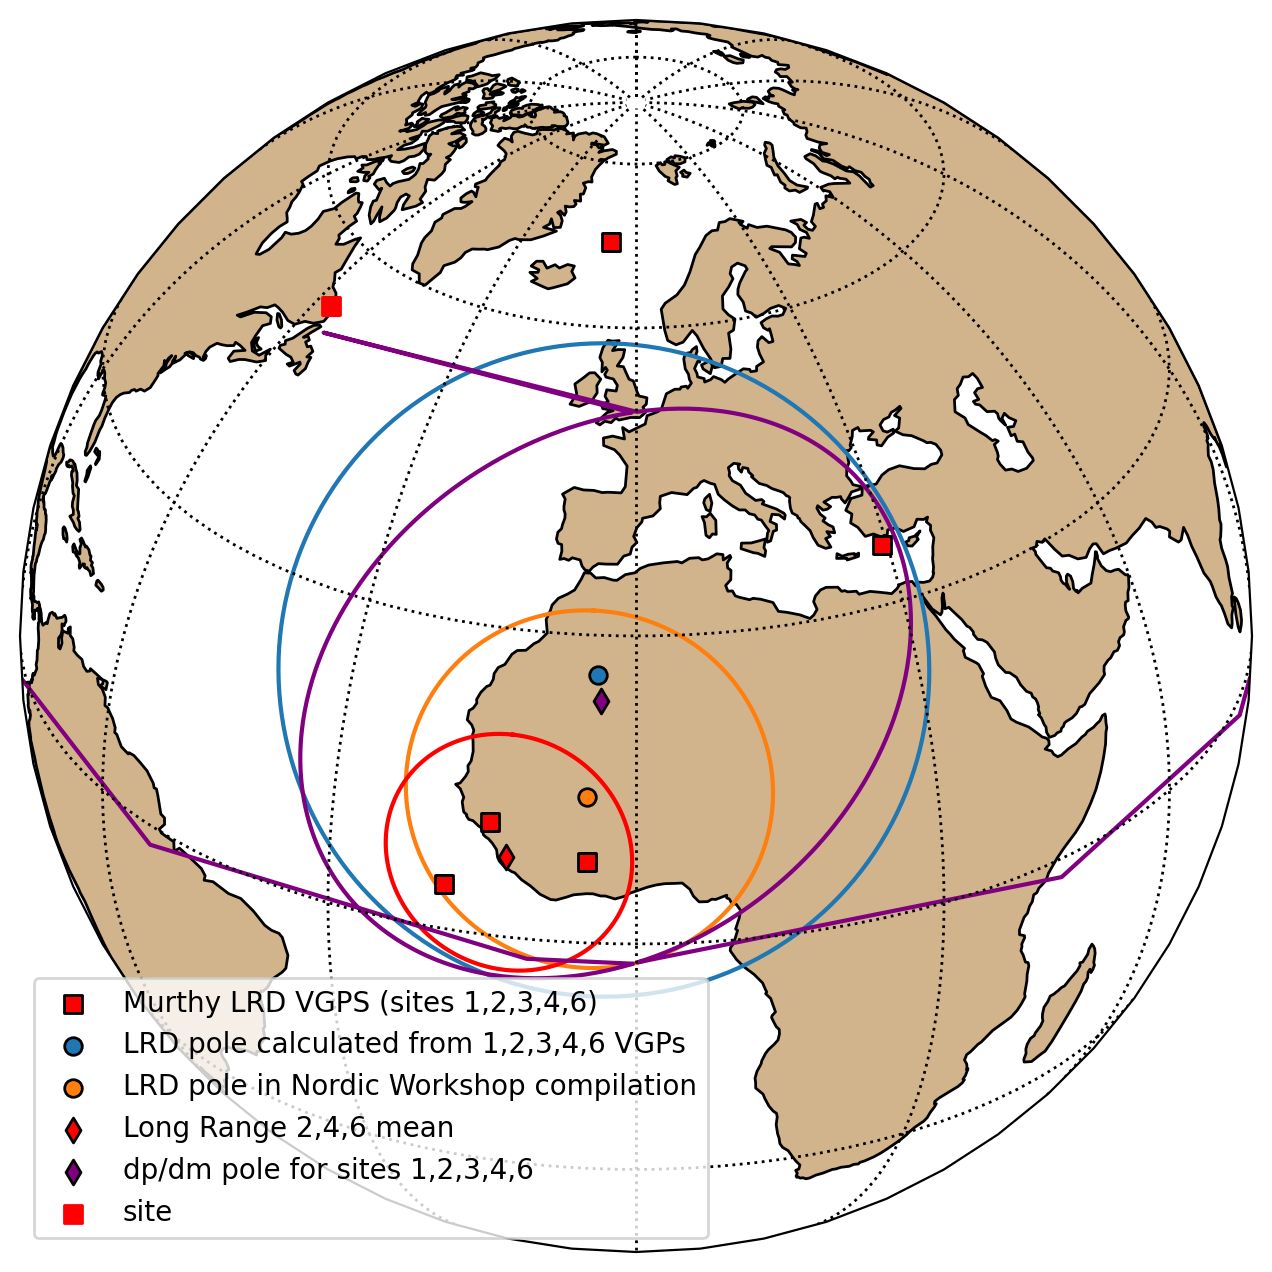

In [33]:
map_axis = ipmag.make_orthographic_map(central_longitude=0,central_latitude=30)
ipmag.plot_vgp(map_axis,di_block=Murthy_vgps,color='r',markersize=40, marker='s',
               label='Murthy LRD VGPS (sites 1,2,3,4,6)')
ipmag.plot_pole(map_axis, LRD_pole['dec'], LRD_pole['inc'], LRD_pole['alpha95'],
                label='LRD pole calculated from 1,2,3,4,6 VGPs',color='C0',markersize=40)
ipmag.plot_pole(map_axis, 355.3, 14.8, 17.4,
                label='LRD pole in Nordic Workshop compilation',color='C1',markersize=40)

ipmag.plot_pole(map_axis, Long_range_246_mean['dec'], Long_range_246_mean['inc'], 
                Long_range_246_mean['alpha95'], color='red', marker='d', markersize=40, label='Long Range 2,4,6 mean')

ipmag.plot_pole_dp_dm(map_axis, LRD_pole_lon_di,
                      LRD_pole_lat_di,
                      Murthy_data['site_lon'][0],
                      Murthy_data['site_lat'][0],
                      LRD_pole_dp_di,
                      LRD_pole_dm_di,
                      pole_color='purple', 
                      pole_marker='d', 
                      markersize=40,
                      pole_label="dp/dm pole for sites 1,2,3,4,6")

plt.legend(loc=3)
plt.show()

In [26]:
ipmag.plot_pole_dp_dm?

Signature:
ipmag.plot_pole_dp_dm(
    map_axis,
    plon,
    plat,
    slon,
    slat,
    dp,
    dm,
    pole_label='pole',
    site_label='site',
    pole_color='k',
    pole_edgecolor='k',
    pole_marker='o',
    site_color='r',
    site_edgecolor='r',
    site_marker='s',
    markersize=20,
    legend=True,
)
Docstring:
This function plots a paleomagnetic pole and a dp/dm confidence ellipse on a cartopy map axis.

Before this function is called, a plot needs to be initialized with code
such as that in the make_orthographic_map function.

Parameters:
    map_axis : the name of the current map axis that has been developed using cartopy
    plon : the longitude of the paleomagnetic pole being plotted (in degrees E)
    plat : the latitude of the paleomagnetic pole being plotted (in degrees)
    slon : the longitude of the site (in degrees E)
    slat : the latitude of the site (in degrees)
    dp : the semi-minor axis of the confidence ellipse (in degrees)
    dm : the semi-major a

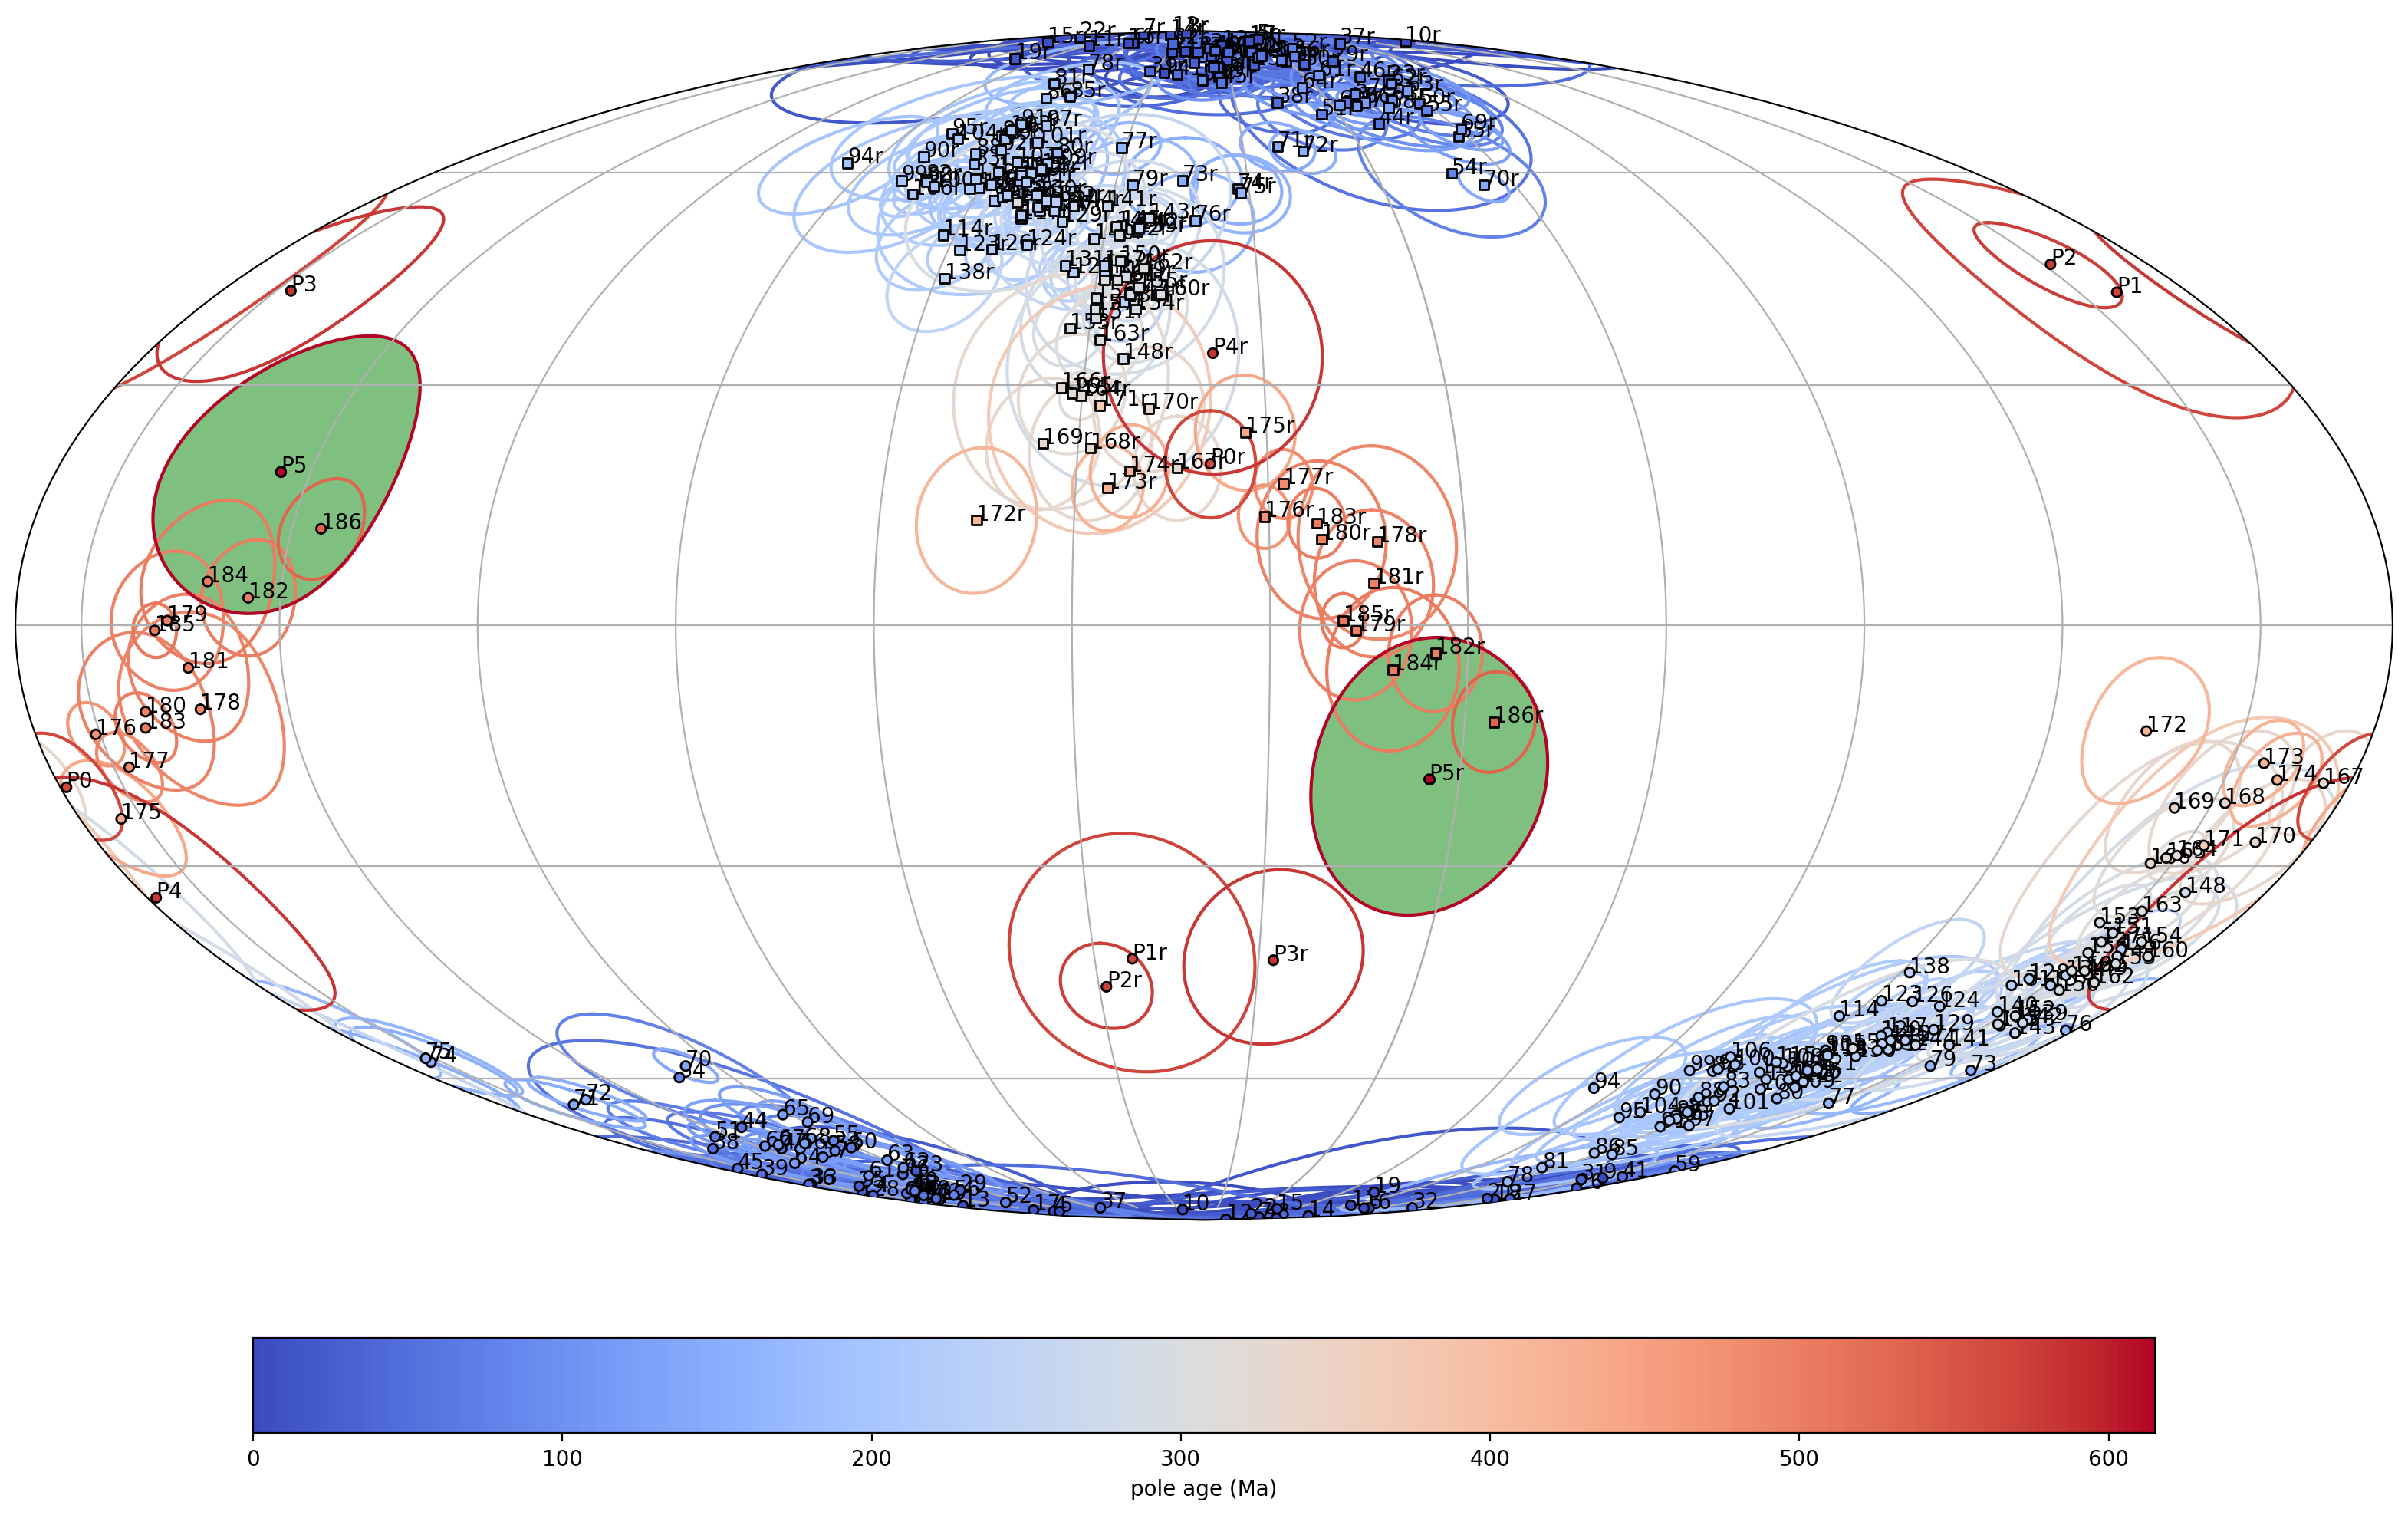

In [27]:
plot_pole_overlap('Long Range Dykes',Laurentia_stricto_poles,Torsvik2012_Laurentia)